In [54]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

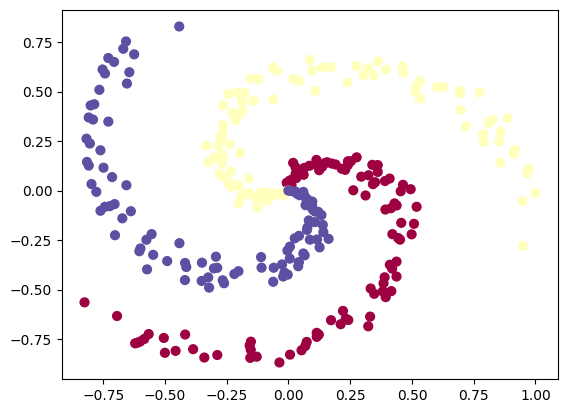

In [55]:
#creating spiral data set for multiclass classification

N = 100 #number of samples
K = 3 #number of classes
D = 2 #dimension of the data
X= np.zeros((N*K,D))
Y = np.zeros(N*K,dtype='uint8')

for j in range(K):
  ix = range(j*N,N*(j+1))
  r = np.linspace(0.0,1,N) #radius
  t = np.linspace(j*4,(j+1)*4,N)+ np.random.randn(N)*0.2 #theta
  X[ix] = np.c_[r*np.sin(t),r*np.cos(t)]
  Y[ix]= j
#lets visualize the data
plt.scatter(X[:,0],X[:,1],c=Y,s=40,cmap=plt.cm.Spectral)
plt.show()


In [56]:
#lets write device agnostic code first
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
#lets prepare the data for training and testing


x_train,x_test,y_train,y_test  = train_test_split(X,Y,
                                                  test_size=0.2,
                                                  random_state=42)
#convert input arrays into tensors
x_train,x_test = torch.from_numpy(x_train).type(torch.float),torch.from_numpy(x_test).type(torch.float)
y_train,y_test = torch.from_numpy(y_train).type(torch.long),torch.from_numpy(y_test).type(torch.long)
len(x_train),len(y_train),len(x_test),len(y_test)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

(torch.Size([240, 2]),
 torch.Size([60, 2]),
 torch.Size([240]),
 torch.Size([60]))

In [59]:
#lets define a model

class MultiClass(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=2,out_features=10)
    self.layer2 = nn.Linear(in_features=10,out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=10)
    self.layer4 = nn.Linear(in_features=10,out_features=3)
    self.relu = nn.ReLU()

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.layer4(self.relu(self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))))

#instanciate the instance of the model and put the model into same train device
model3 = MultiClass().to(device)


In [60]:
#create a loss function ooptimizer and accuracy

import torchmetrics
from torchmetrics import Accuracy

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model3.parameters(),
                              lr=0.1)

torchmetrics_accuracy = Accuracy(task="multiclass",num_classes=3).to(device)


In [62]:
#lets train the model then
#start with random seed
torch.manual_seed(42)

#put the data into the same train device as model
x_train,x_test,y_train,y_test = x_train.to(device),x_test.to(device),y_train.to(device),y_test.to(device)

epochs = 1000
for epoch in range(epochs):
  model3.train()

  #forward pass
  y_logits = model3(x_train)
  y_preds = torch.round(torch.softmax(y_logits,dim=1)).argmax(dim=1)

  #calculate the loss and accuracy
  loss = loss_fn(y_logits,y_train)
  accuracy = torchmetrics_accuracy(y_preds,y_train)

  #optimize the zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimzer step
  optimizer.step()

  #evaluate the model
  model3.eval()
  with torch.inference_mode():
    test_logits = model3(x_test)
    test_preds = torch.round(torch.softmax(test_logits,dim=1)).argmax(dim=1)

    #calculate the test loss and accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_accuracy = torchmetrics_accuracy(test_logits,y_test)

    if epoch %100 ==0:
      print(f"Epoch:{epoch} loss:{loss} |  accuracy:{accuracy} | test_loss:{test_loss}| test_accuracy:{test_accuracy}")








Epoch:0 loss:0.07732025533914566 |  accuracy:0.9708333611488342 | test_loss:0.11322391778230667| test_accuracy:0.9666666388511658
Epoch:100 loss:0.07040704041719437 |  accuracy:0.9708333611488342 | test_loss:0.1065957173705101| test_accuracy:0.9666666388511658
Epoch:200 loss:0.06847015768289566 |  accuracy:0.9708333611488342 | test_loss:0.09831048548221588| test_accuracy:0.9833333492279053
Epoch:300 loss:0.06185191497206688 |  accuracy:0.9791666865348816 | test_loss:0.09510461241006851| test_accuracy:0.9833333492279053
Epoch:400 loss:0.06083447486162186 |  accuracy:0.9791666865348816 | test_loss:0.1057138666510582| test_accuracy:0.9666666388511658
Epoch:500 loss:0.0623844712972641 |  accuracy:0.9791666865348816 | test_loss:0.0957694873213768| test_accuracy:0.9833333492279053
Epoch:600 loss:0.059231556951999664 |  accuracy:0.9833333492279053 | test_loss:0.0960988998413086| test_accuracy:0.9833333492279053
Epoch:700 loss:0.057431355118751526 |  accuracy:0.9833333492279053 | test_loss:0.0

In [64]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


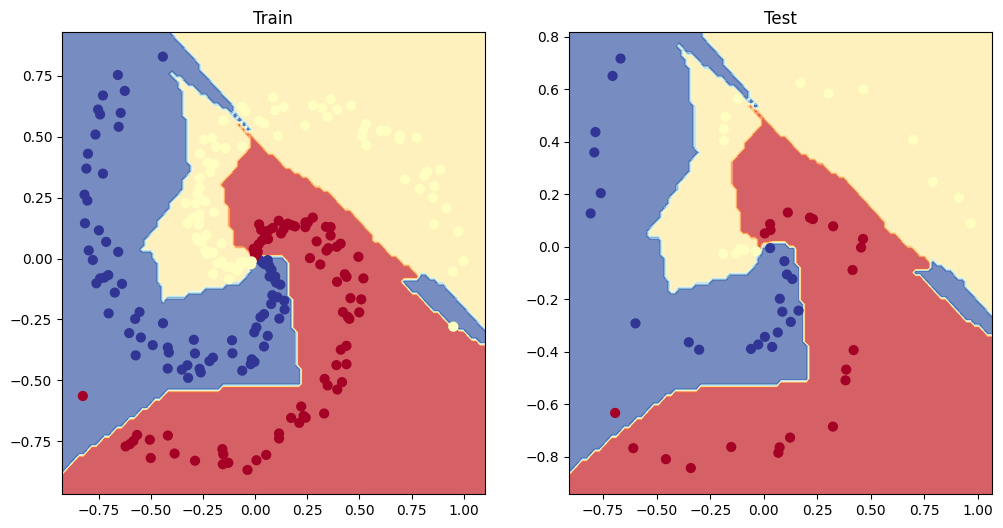

In [65]:
#plot the train and test of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model3, x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model3,x_test,y_test)
